## 1. Imports


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('colorblind')

## 2. Dataset loading and EDA


Dataset Shape: (14204, 13)

Data Types:
Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
source                           str
dtype: object

Missing Values Count:
Item_Weight          2439
Outlet_Size          4016
Item_Outlet_Sales    5681
dtype: int64

Duplicate Rows: 0

Numerical Features Summary:
        Item_Weight  Item_Visibility      Item_MRP  Outlet_Establishment_Year  \
count  11765.000000     14204.000000  14204.000000               14204.000000   
mean      12.792854         0.065953    141.004977                1997.830681   
std        4.652502         0.051459     62.086938          

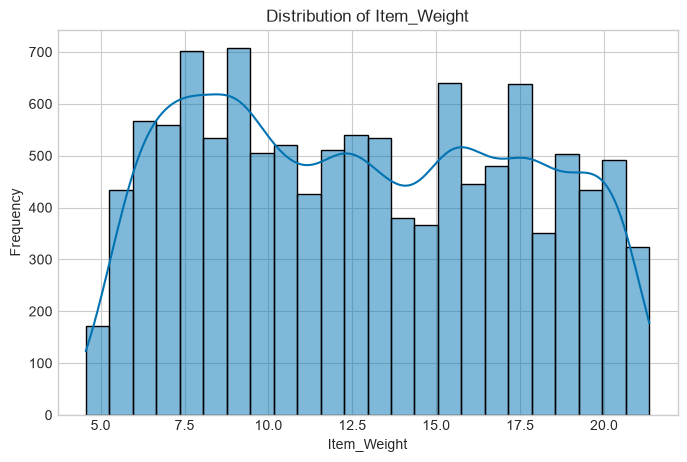

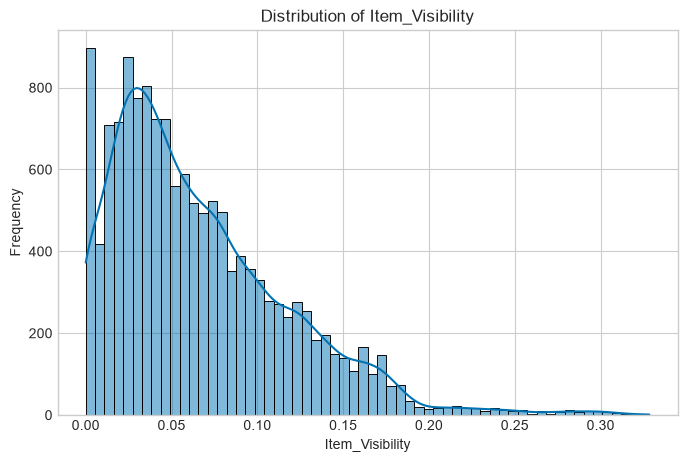

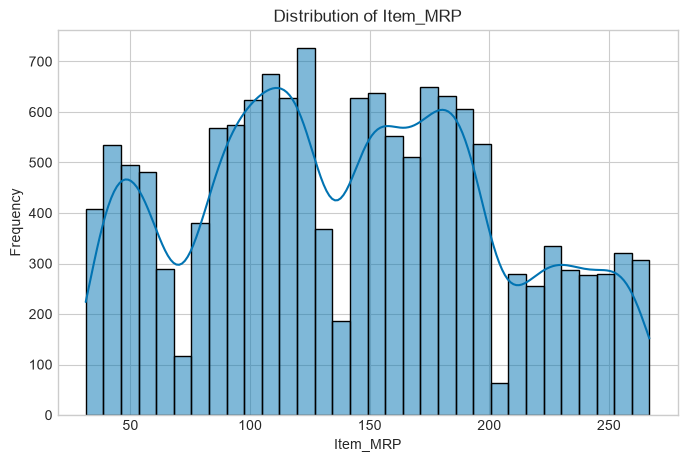

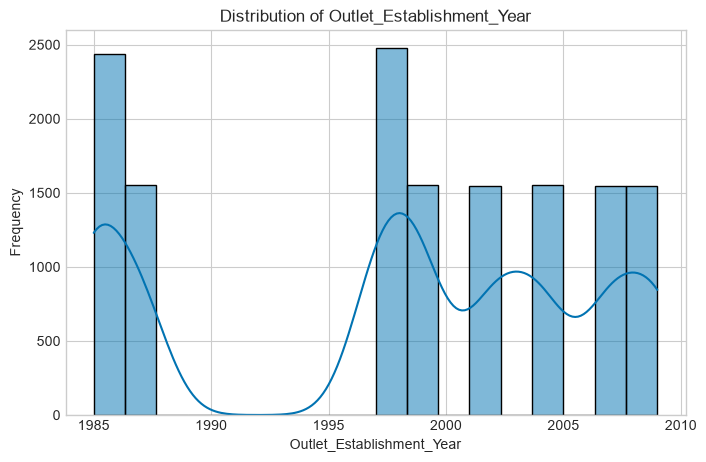

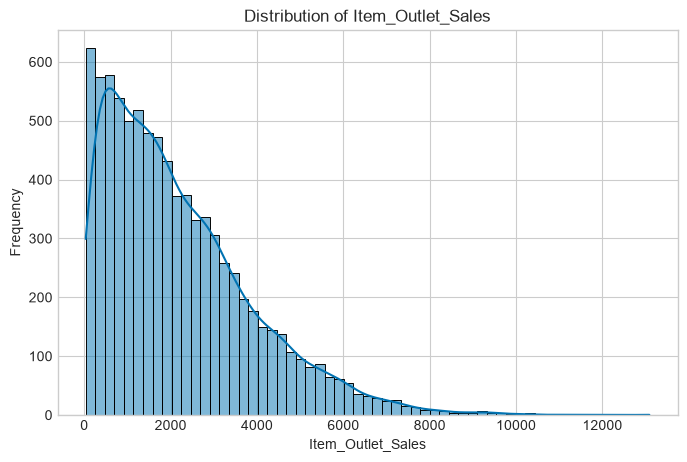

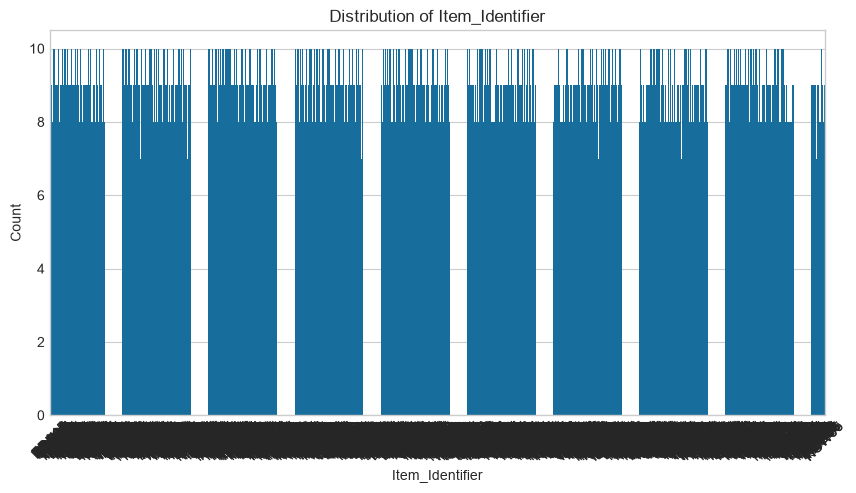

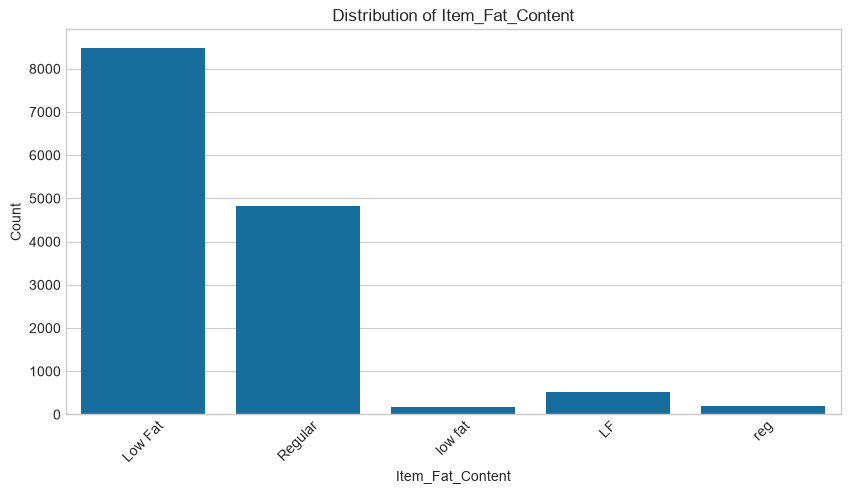

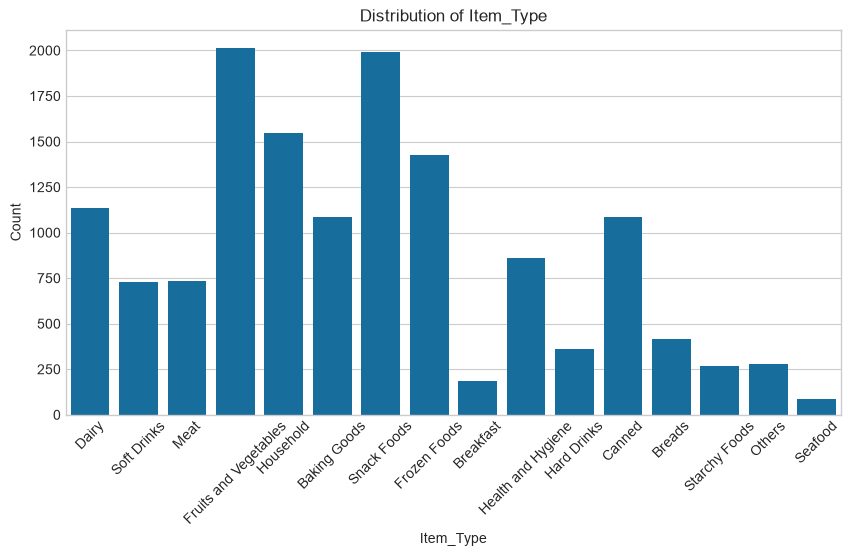

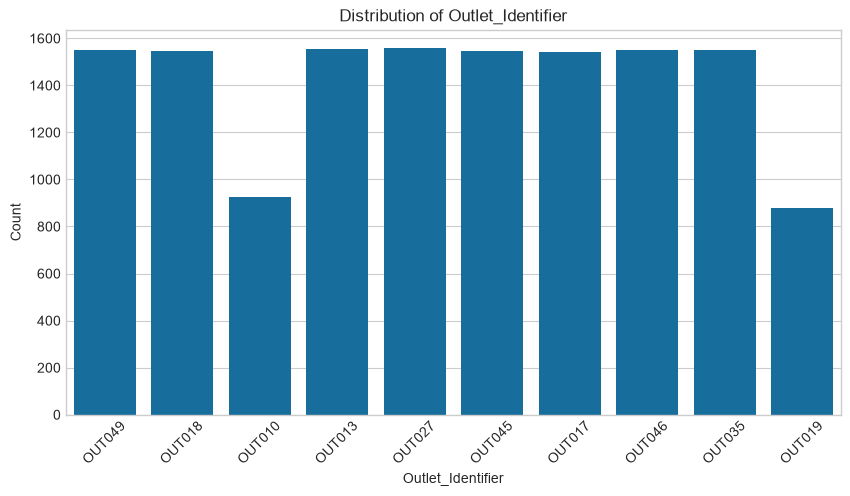

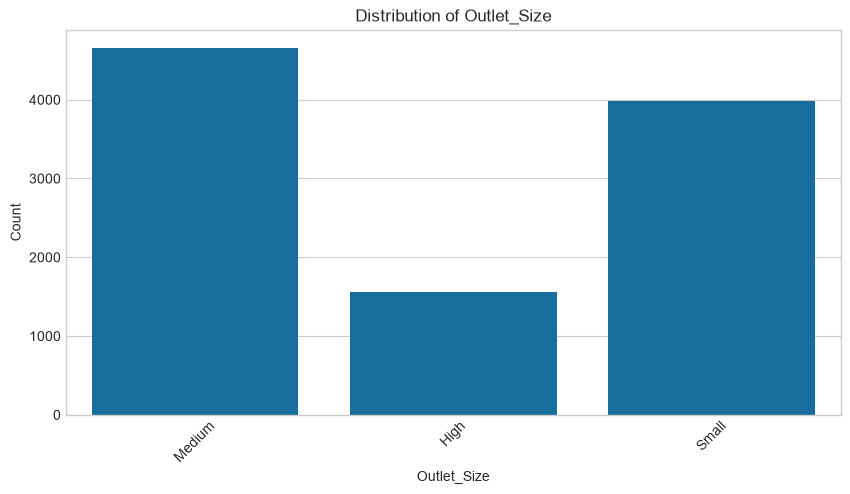

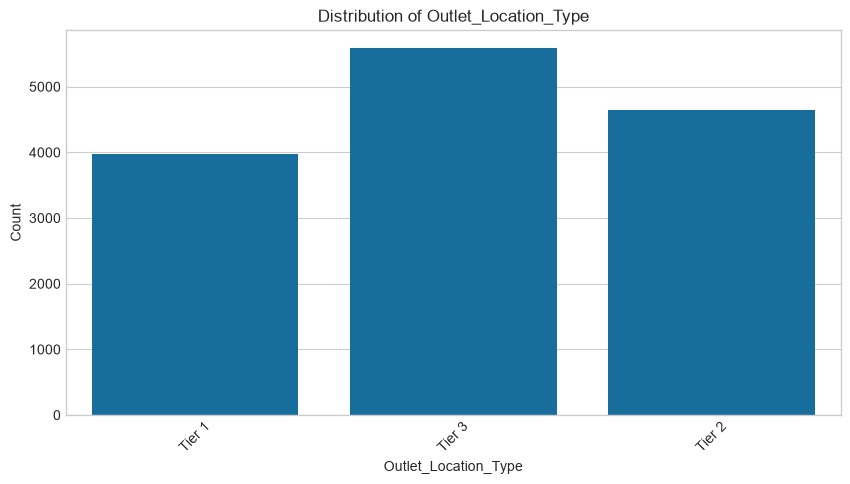

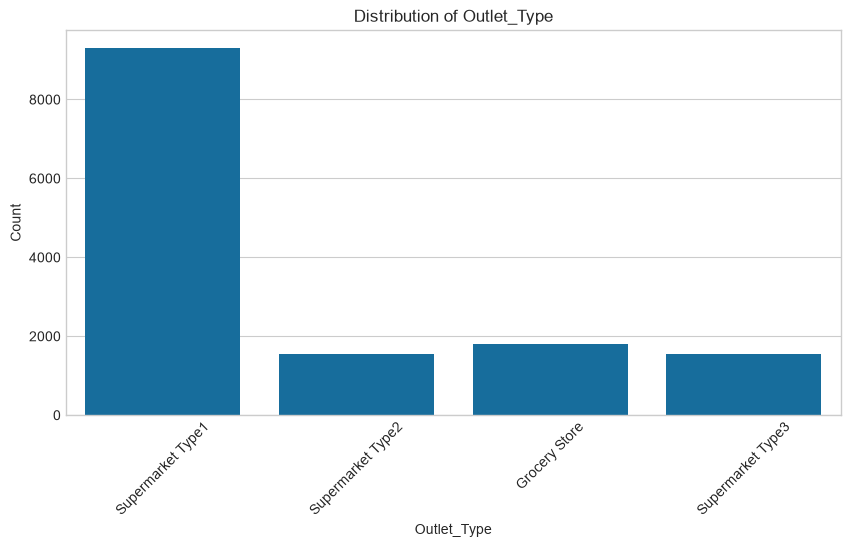

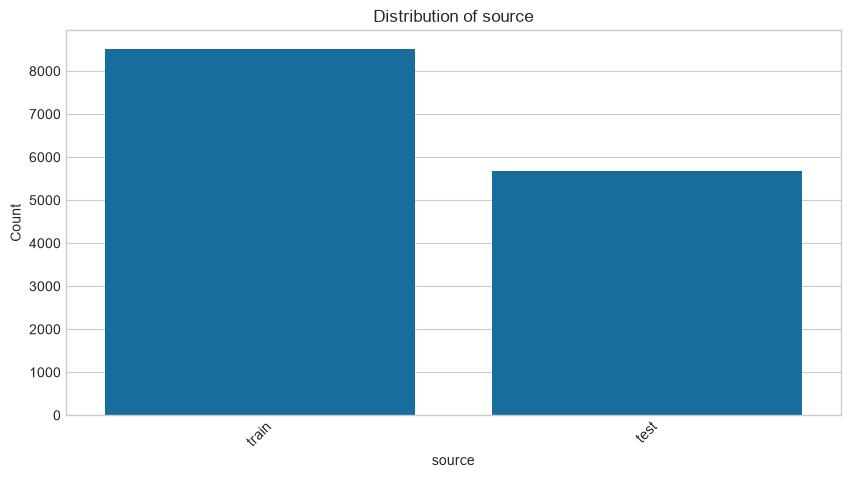

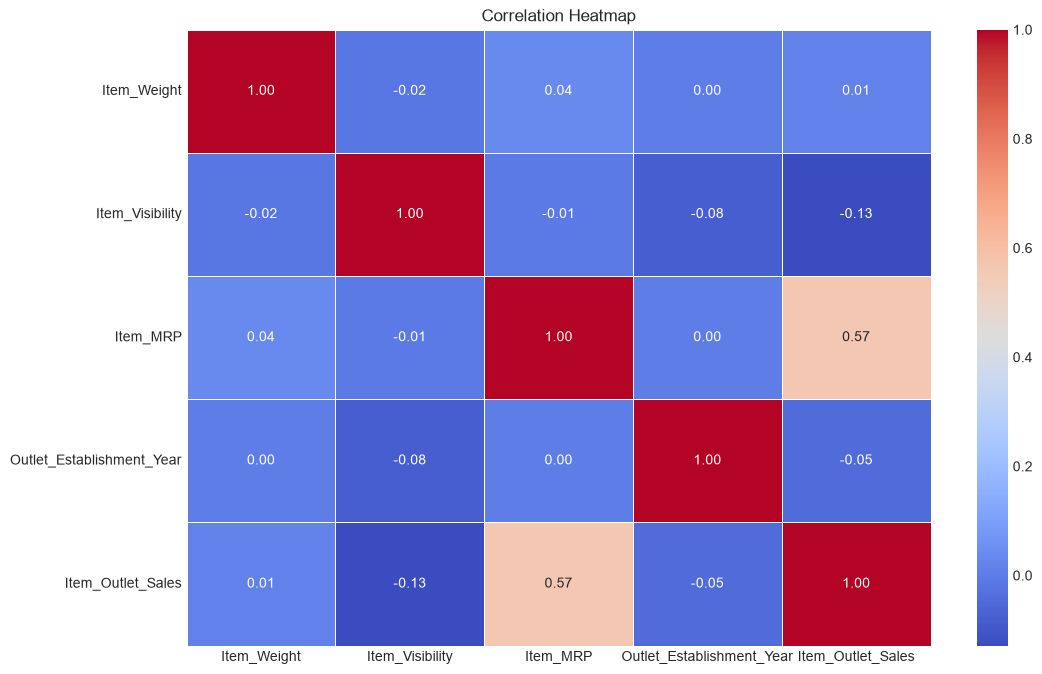

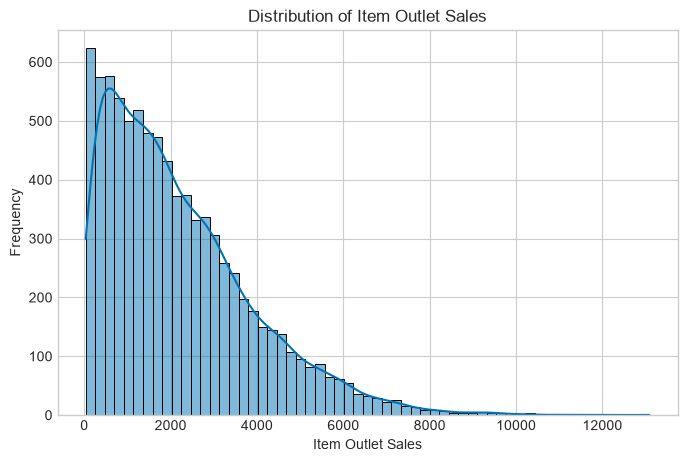

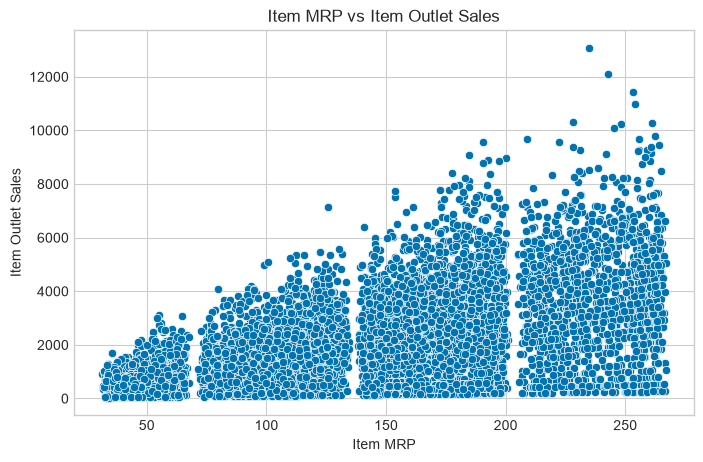

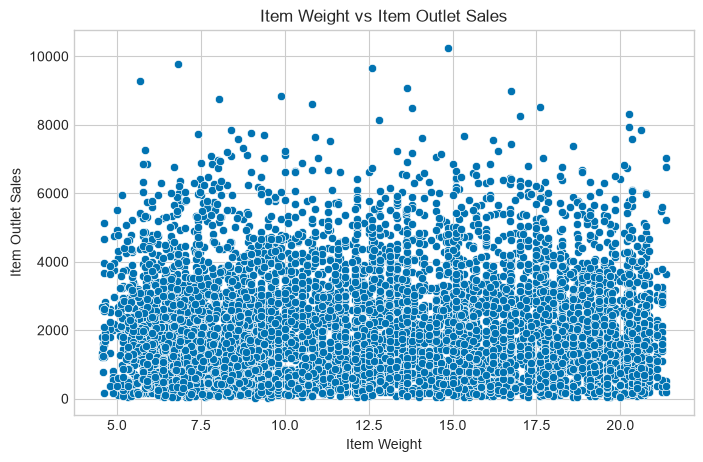

In [10]:
data_path = r'data/regression/data.csv'
df = pd.read_csv(data_path)

print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values Count:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nNumerical Features Summary:")
print(df.describe())

print("\nCategorical Features Summary:")
print(df.describe(include='object'))

print("\nTarget Distribution Summary ('Item_Outlet_Sales'):")
print(df['Item_Outlet_Sales'].describe())

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature].dropna(), kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

for feature in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=feature)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['Item_Outlet_Sales'].dropna(), kde=True)
plt.title('Distribution of Item Outlet Sales')
plt.xlabel('Item Outlet Sales')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Item_MRP',
    y='Item_Outlet_Sales'
)

plt.title('Item MRP vs Item Outlet Sales')
plt.xlabel('Item MRP')
plt.ylabel('Item Outlet Sales')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Item_Weight',
    y='Item_Outlet_Sales'
)

plt.title('Item Weight vs Item Outlet Sales')
plt.xlabel('Item Weight')
plt.ylabel('Item Outlet Sales')
plt.show()

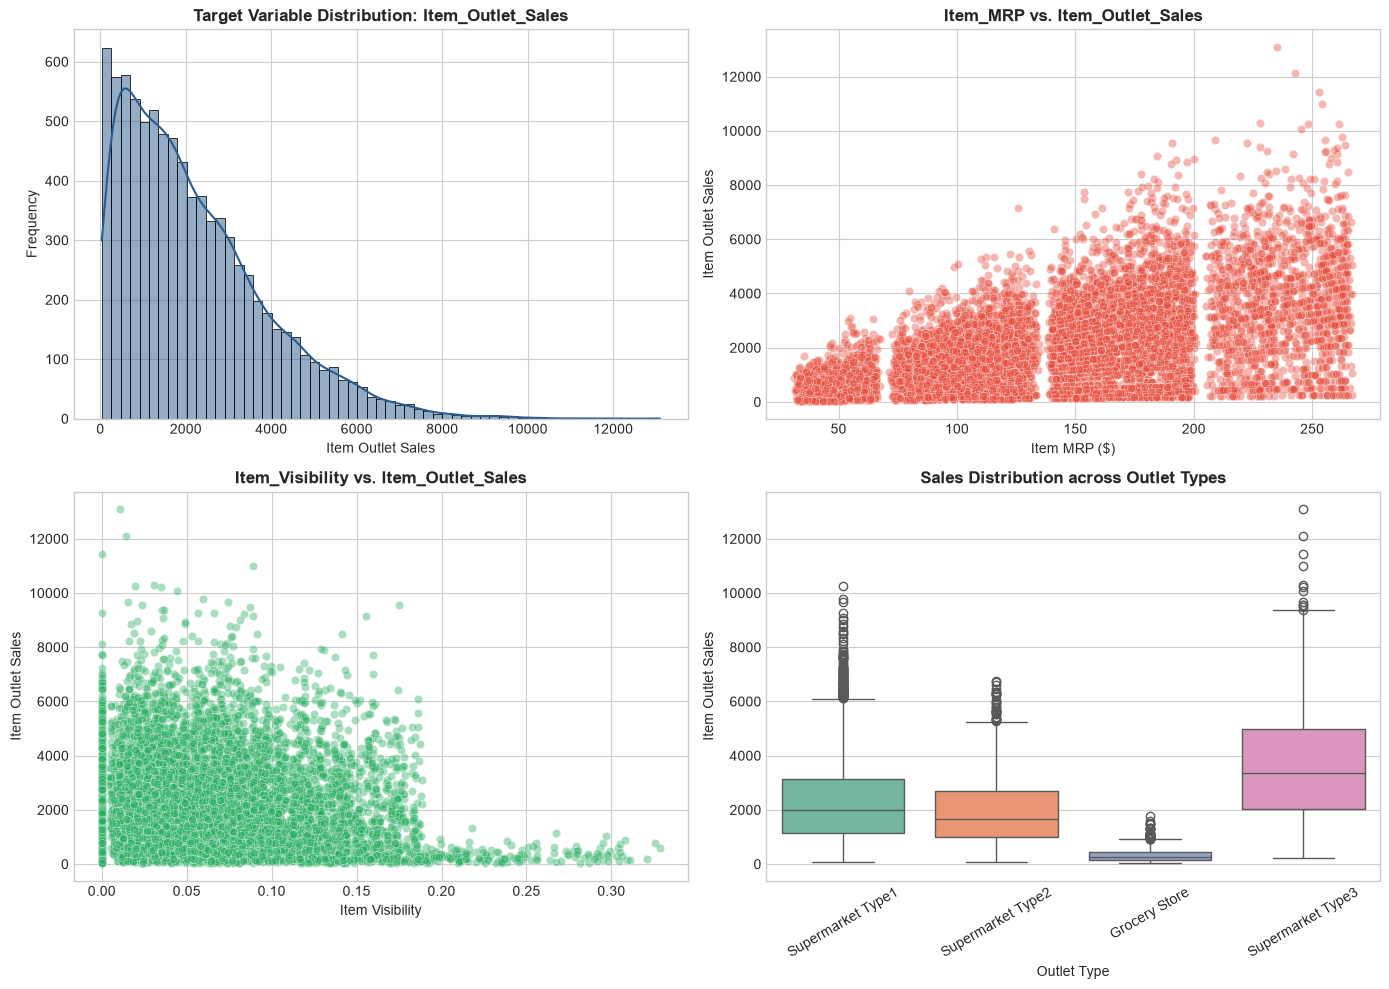

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Distribution Plot
sns.histplot(df['Item_Outlet_Sales'].dropna(), kde=True, ax=axes[0, 0], color='#2b5c8f')
axes[0, 0].set_title('Target Variable Distribution: Item_Outlet_Sales', fontweight='bold')
axes[0, 0].set_xlabel('Item Outlet Sales')
axes[0, 0].set_ylabel('Frequency')

# 2. Item MRP vs Item Outlet Sales Scatter Plot
sns.scatterplot(data=df, x='Item_MRP', y='Item_Outlet_Sales', alpha=0.4, ax=axes[0, 1], color='#e74c3c')
axes[0, 1].set_title('Item_MRP vs. Item_Outlet_Sales', fontweight='bold')
axes[0, 1].set_xlabel('Item MRP ($)')
axes[0, 1].set_ylabel('Item Outlet Sales')

# 3. Item Visibility vs Item Outlet Sales Scatter Plot
sns.scatterplot(data=df, x='Item_Visibility', y='Item_Outlet_Sales', alpha=0.4, ax=axes[1, 0], color='#27ae60')
axes[1, 0].set_title('Item_Visibility vs. Item_Outlet_Sales', fontweight='bold')
axes[1, 0].set_xlabel('Item Visibility')
axes[1, 0].set_ylabel('Item Outlet Sales')

# 4. Sales by Outlet Type Boxplot
sns.boxplot(data=df, x='Outlet_Type', y='Item_Outlet_Sales', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Sales Distribution across Outlet Types', fontweight='bold')
axes[1, 1].set_xlabel('Outlet Type')
axes[1, 1].set_ylabel('Item Outlet Sales')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 3. Preprocessing


In [12]:
# 1. Clean & Standardize Item_Fat_Content
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'})

# 2. Impute Missing Item_Weight (mean per Item_Identifier with global mean fallback)
df['Item_Weight'] = df.groupby('Item_Identifier')['Item_Weight'].transform(lambda x: x.fillna(x.mean()))
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

# 3. Impute Missing Outlet_Size (mode per Outlet_Type with 'Medium' fallback)
outlet_size_mode = df.groupby('Outlet_Type')['Outlet_Size'].apply(lambda x: x.mode()[0] if not x.mode().empty else 'Medium').to_dict()
df['Outlet_Size'] = df.apply(lambda x: outlet_size_mode[x['Outlet_Type']] if pd.isna(x['Outlet_Size']) else x['Outlet_Size'], axis=1)

# 4. Handle Item_Visibility 0 values
item_visibility_mean = df.groupby('Item_Identifier')['Item_Visibility'].mean()
df['Item_Visibility'] = df.apply(lambda x: item_visibility_mean[x['Item_Identifier']] if x['Item_Visibility'] == 0 else x['Item_Visibility'], axis=1)

# 5. Feature Engineering: Item_Category and Outlet_Age
df['Item_Category'] = df['Item_Identifier'].apply(lambda x: x[:2])
df.loc[df['Item_Category'] == 'NC', 'Item_Fat_Content'] = 'Non-Edible'
df['Outlet_Age'] = 2013 - df['Outlet_Establishment_Year']

# 6. Separate Train and Test subsets
train_df = df[df['source'] == 'train'].copy()
test_df = df[df['source'] == 'test'].copy()

# Drop identifier columns not used as direct features
drop_cols = ['Item_Identifier', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'source']
train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols + ['Item_Outlet_Sales'], inplace=True)

# 7. Ordinal Encoding
outlet_size_map = {'Small': 0, 'Medium': 1, 'High': 2}
outlet_location_map = {'Tier 1': 0, 'Tier 2': 1, 'Tier 3': 2}

train_df['Outlet_Size'] = train_df['Outlet_Size'].map(outlet_size_map).fillna(1).astype(int)
train_df['Outlet_Location_Type'] = train_df['Outlet_Location_Type'].map(outlet_location_map).fillna(1).astype(int)
test_df['Outlet_Size'] = test_df['Outlet_Size'].map(outlet_size_map).fillna(1).astype(int)
test_df['Outlet_Location_Type'] = test_df['Outlet_Location_Type'].map(outlet_location_map).fillna(1).astype(int)

# 8. One-Hot Encoding for Nominal Features
categorical_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Type', 'Item_Category']
train_df = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)

# Align columns between train and test
train_cols = train_df.columns.drop('Item_Outlet_Sales')
for col in train_cols:
    if col not in test_df.columns:
        test_df[col] = 0
test_df = test_df[train_cols]

# 9. Feature Engineering: Engineered Features for Improved Predictability
# Feature A: Price_per_Weight (Item_MRP / Item_Weight)
#   Captures value density - a high price-per-gram item signals a premium product
#   with higher impulse purchase appeal, independent of raw weight or MRP alone.
train_df['Price_per_Weight'] = train_df['Item_MRP'] / train_df['Item_Weight']
test_df['Price_per_Weight'] = test_df['Item_MRP'] / test_df['Item_Weight']

# Feature B: Outlet_Age_Size (Outlet_Age * Outlet_Size)
#   Captures the compounded effect of outlet maturity and size.
#   A large, well-established store has a wider customer base and better
#   inventory management, leading to higher sustained sales volumes.
outlet_size_num_map = {'Small': 1, 'Medium': 2, 'High': 3}
train_df['Outlet_Size_Num'] = train_df['Outlet_Size'].map({0: 1, 1: 2, 2: 3})
test_df['Outlet_Size_Num'] = test_df['Outlet_Size'].map({0: 1, 1: 2, 2: 3})
train_df['Outlet_Age_Size'] = train_df['Outlet_Age'] * train_df['Outlet_Size_Num']
test_df['Outlet_Age_Size'] = test_df['Outlet_Age'] * test_df['Outlet_Size_Num']
train_df.drop(columns=['Outlet_Size_Num'], inplace=True)
test_df.drop(columns=['Outlet_Size_Num'], inplace=True)

# Define Features and Target
X = train_df.drop('Item_Outlet_Sales', axis=1)
y = train_df['Item_Outlet_Sales']

# Train/Validation Split (80:20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit StandardScaler ONLY on X_train (No Data Leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
test_scaled = scaler.transform(test_df)

# Global results list to store metric evaluation for all 10 algorithms
results_list = []

print("Preprocessing complete!")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_val shape: {X_val_scaled.shape}")

Preprocessing complete!
X_train shape: (6818, 30)
X_val shape: (1705, 30)


## 4. Model initialization, Training, Predicting


In [13]:
k_values = list(range(1, 21))
train_r2 = []
val_r2 = []

for k in k_values:
    knn_temp = KNeighborsRegressor(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    
    train_pred = knn_temp.predict(X_train_scaled)
    val_pred = knn_temp.predict(X_val_scaled)
    
    train_r2.append(r2_score(y_train, train_pred))
    val_r2.append(r2_score(y_val, val_pred))

best_k = k_values[np.argmax(val_r2)]

knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

predicted_sales = knn.predict(X_val_scaled)



## 5. Evaluation metrics of the model


In [14]:
r2_score_knn = r2_score(y_val, predicted_sales)
rmse_knn = np.sqrt(mean_squared_error(y_val, predicted_sales))
mae_knn = mean_absolute_error(y_val, predicted_sales)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    knn,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring='r2'
)

average_cv_r2 = np.mean(cv_scores)
std_cv_r2 = np.std(cv_scores)

results_list.append({
    'Algorithm': f'KNN Regressor (K={best_k})',
    'R2 Score': r2_score_knn,
    'RMSE': rmse_knn,
    'MAE': mae_knn,
    '5-Fold CV R2': average_cv_r2,
    '5-Fold CV Std': std_cv_r2
})

print("=" * 60)
print(" KNN REGRESSOR PERFORMANCE METRICS ")
print("=" * 60)
print(f"Best K Value            : {best_k}")
print(f"Validation R² Score     : {r2_score_knn:.4f}")
print(f"Validation RMSE         : {rmse_knn:.4f}")
print(f"Validation MAE          : {mae_knn:.4f}")
print(f"5-Fold CV R² Mean Score : {average_cv_r2:.4f} (+/- {std_cv_r2:.4f})")
print("=" * 60)




 KNN REGRESSOR PERFORMANCE METRICS 
Best K Value            : 10
Validation R² Score     : 0.5105
Validation RMSE         : 1153.5069
Validation MAE          : 837.2477
5-Fold CV R² Mean Score : 0.4758 (+/- 0.0173)


## 6. Graphs

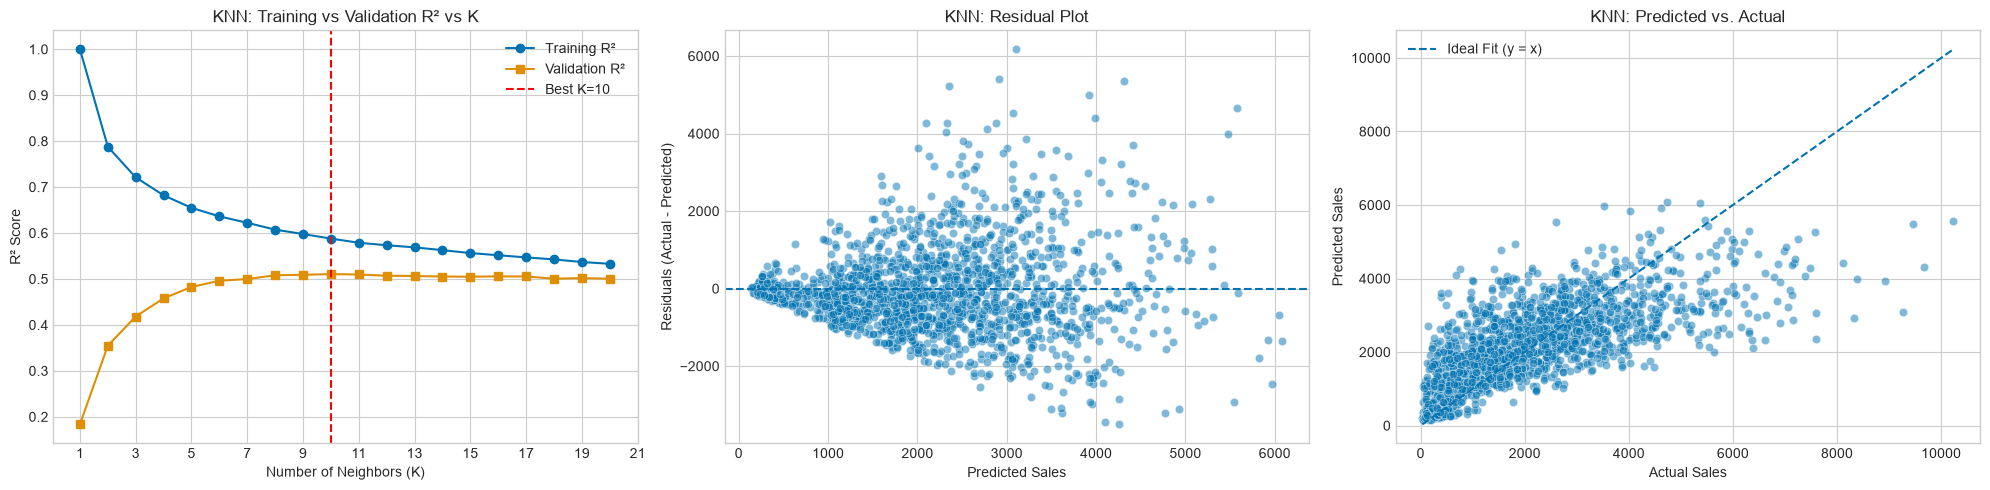

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Training vs Validation R² vs K
axes[0].plot(k_values, train_r2, marker='o', label='Training R²')
axes[0].plot(k_values, val_r2, marker='s', label='Validation R²')
axes[0].axvline(best_k, color='r', linestyle='--', label=f'Best K={best_k}')
axes[0].set_title('KNN: Training vs Validation R² vs K')
axes[0].set_xlabel('Number of Neighbors (K)')
axes[0].set_ylabel('R² Score')
axes[0].set_xticks(range(1, 22, 2))
axes[0].legend()

# Residual Plot
residuals = y_val - predicted_sales

sns.scatterplot(
    x=predicted_sales,
    y=residuals,
    alpha=0.5,
    ax=axes[1]
)

axes[1].axhline(0, linestyle='--')
axes[1].set_title('KNN: Residual Plot')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

# Predicted vs Actual
sns.scatterplot(
    x=y_val,
    y=predicted_sales,
    alpha=0.5,
    ax=axes[2]
)

minimum = min(y_val.min(), predicted_sales.min())
maximum = max(y_val.max(), predicted_sales.max())

axes[2].plot(
    [minimum, maximum],
    [minimum, maximum],
    '--',
    linewidth=1.5,
    label='Ideal Fit (y = x)'
)

axes[2].set_title('KNN: Predicted vs. Actual')
axes[2].set_xlabel('Actual Sales')
axes[2].set_ylabel('Predicted Sales')
axes[2].legend()

plt.tight_layout()
plt.show()